In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook')
import warnings

warnings.filterwarnings('ignore')

In [16]:
import pandas as pd

# Load the parquet file
df = pd.read_parquet("D:/Study/data_science/underpriced-listing-predictor/data/03.cleaned/multi_appliances_cleaned.parquet")

# Initial checks
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Shape: (2900, 54)

First 5 rows:


,price,rating,category,n_features,brand_name,capacity_value,capacity_unit,star_rating,has_star_rating,has_inverter,...,wm_washer_only,wm_dryer_only,wm_front_load,wm_top_load,wm_inbuilt_heater,wm_quick_wash,wm_ss_tub,wm_child_lock,wm_shock_proof,wm_display
0,24990,4.65,AC,10,Whirlpool,1.5,Ton,5.0,1,0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,22990,4.55,AC,11,Carrier,1.5,Ton,3.0,1,1,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,67990,4.10,AC,12,O General,1.5,Ton,5.0,1,1,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,37990,4.55,AC,11,Haier,1.5,Ton,5.0,1,1,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,22990,4.55,AC,11,Voltas,1.5,Ton,3.0,1,0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [17]:
# Summary statistics
print("Summary Stats:")
display(df.describe(include='all').T)

# Data types and missing values
print("\nData Info:")
df.info()

# Unique values (for categorical columns)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    print(f"\nUnique values in {col}: {df[col].nunique()}")



Summary Stats:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
price,2900.0,NaN,NaN,NaN,33386.404138,22406.786046,3990.0,18990.0,30990.0,39990.0,397990.0
rating,2900.0,NaN,NaN,NaN,4.367707,0.236209,3.0,4.15,4.35,4.55,5.0
category,2900,3,AC,1009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_features,2900.0,NaN,NaN,NaN,10.046552,1.83379,2.0,9.0,10.0,11.0,18.0
brand_name,2900,63,Haier,309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capacity_value,2900.0,NaN,NaN,NaN,102.635559,157.923562,0.6,1.5,8.0,190.0,809.0
capacity_unit,2900,3,Ton,1009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
star_rating,1936.0,NaN,NaN,NaN,3.318182,1.151115,1.0,3.0,3.0,4.25,5.0
has_star_rating,2900.0,NaN,NaN,NaN,0.695517,0.460267,0.0,0.0,1.0,1.0,1.0
has_inverter,2900.0,NaN,NaN,NaN,0.534483,0.498896,0.0,0.0,1.0,1.0,1.0



Data Info:
<class 'pandas.DataFrame'>
Index: 2900 entries, 0 to 2924
Data columns (total 54 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     2900 non-null   int64  
 1   rating                    2900 non-null   float64
 2   category                  2900 non-null   str    
 3   n_features                2900 non-null   int64  
 4   brand_name                2900 non-null   str    
 5   capacity_value            2900 non-null   float64
 6   capacity_unit             2900 non-null   str    
 7   star_rating               1936 non-null   float64
 8   has_star_rating           2900 non-null   int64  
 9   has_inverter              2900 non-null   int64  
 10  has_wifi                  2900 non-null   int64  
 11  has_voice_control         2900 non-null   int64  
 12  has_app_control           2900 non-null   int64  
 13  smart_connectivity_score  2900 non-null   int64  
 14  model_year  

### **UNIVARIATE ANALYSIS**

### ***1. Target Variable Distribution***

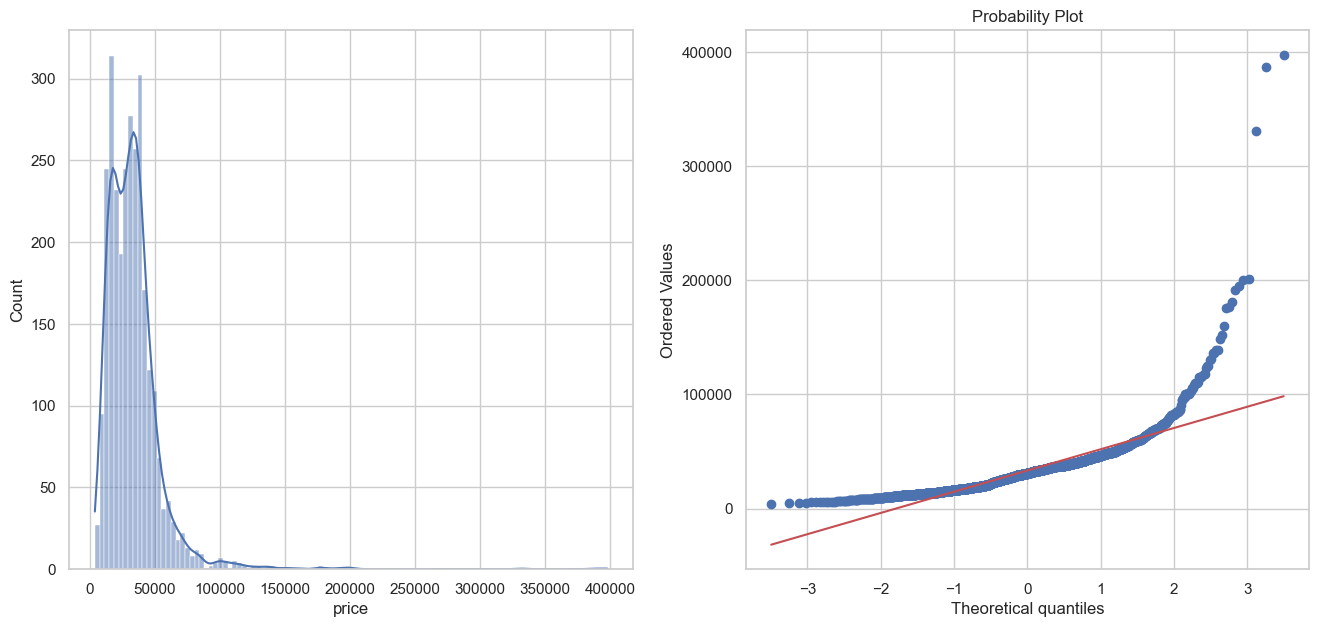

In [18]:
import scipy.stats as stats
fig,ax = plt.subplots(ncols=2,figsize=(16,7))
sns.histplot(data=df,x='price' , kde=True , ax = ax[0])
stats.probplot(df['price'] , plot=ax[1])
plt.show()

**What This Means**:
- Most products cluster in the ₹10K-₹50K range (interquartile range)
- Few luxury products extend to ₹400K (premium segment)

In [19]:
print(f'Skewness -> {df['price'].skew()}')
print(f'Kurtosis -> {df['price'].kurtosis()}')

Skewness -> 5.3709105029917765
Kurtosis -> 63.08121656023925


- Highly right skewed Data

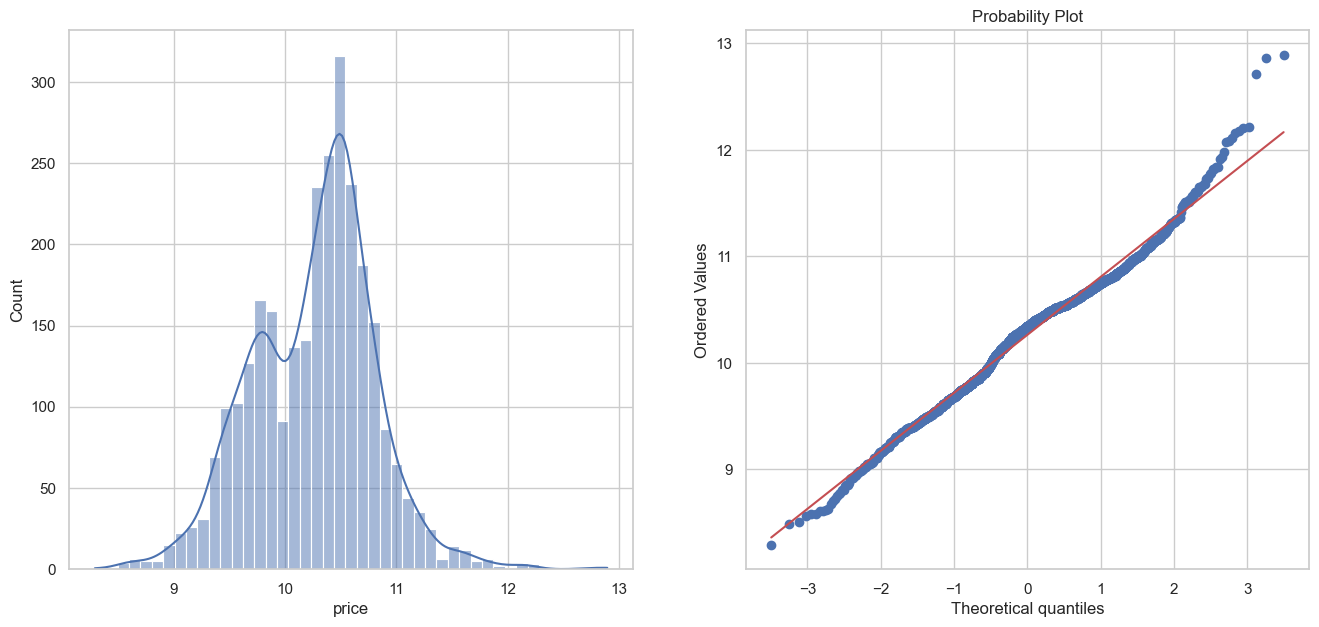

In [20]:
# After Applying log Transformation
log_price = np.log1p(df['price'])
fig,ax = plt.subplots(ncols=2,figsize=(16,7))
sns.histplot(x=log_price , kde=True , ax = ax[0])
stats.probplot(log_price , plot=ax[1])
plt.show()

In [21]:
print(f'Skewness -> {log_price.skew()}')
print(f'Kurtosis -> {log_price.kurtosis()}')

Skewness -> -0.03458786958550277
Kurtosis -> 0.6481017185013185


- See the Data is sort of normally distributed NOW!! 

### ***Categorical Columns***

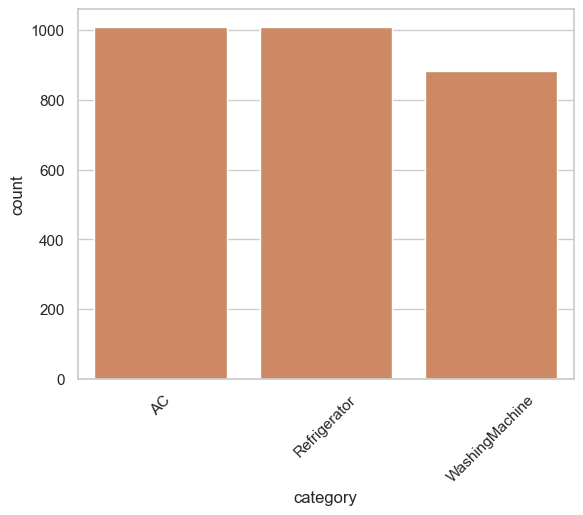

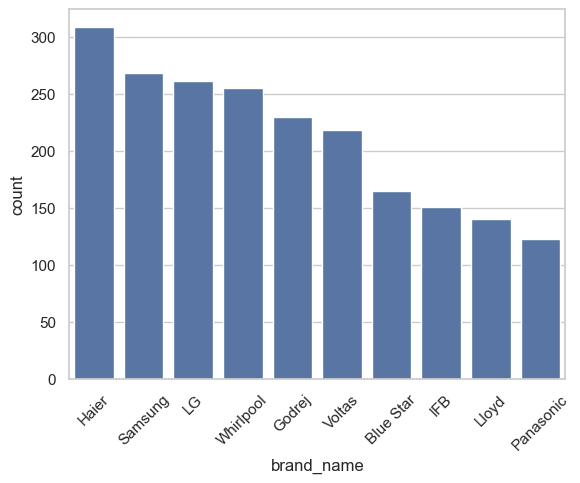

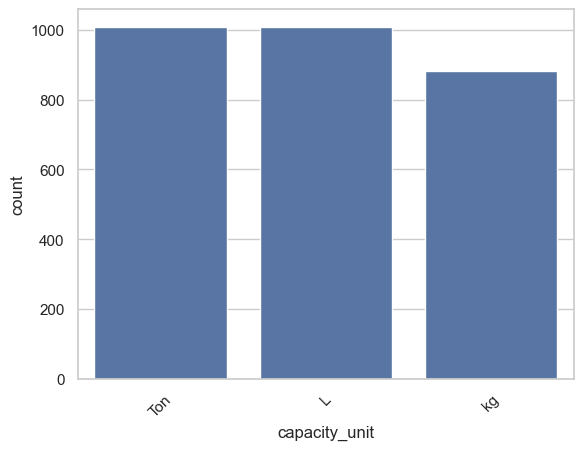

In [44]:
cat_cols = df.select_dtypes(include=['str']).columns.tolist()
for feat in cat_cols:
    if feat =='brand_name':
        sns.barplot(df[feat].value_counts().head(10))
    else:
        sns.barplot(df[feat].value_counts())
    plt.xticks(rotation=45)
    plt.show()

- This balanced distribution is excellent for multi-category modeling. Each category has sufficient samples (880+) for category-specific feature engineering.

### ***Universal Numeric Columns*** 

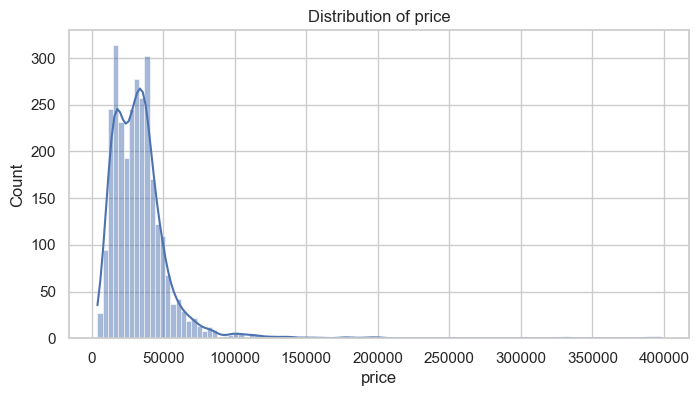

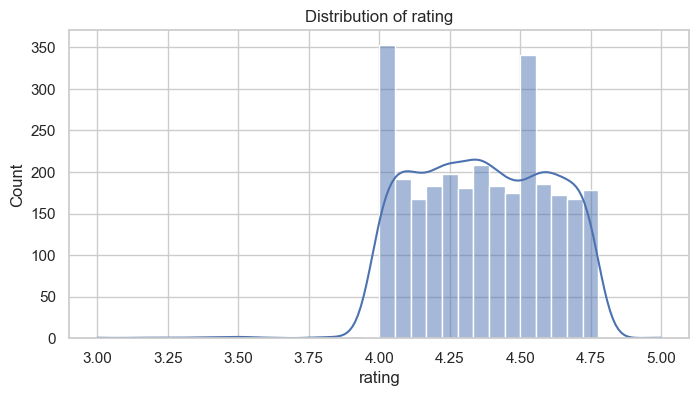

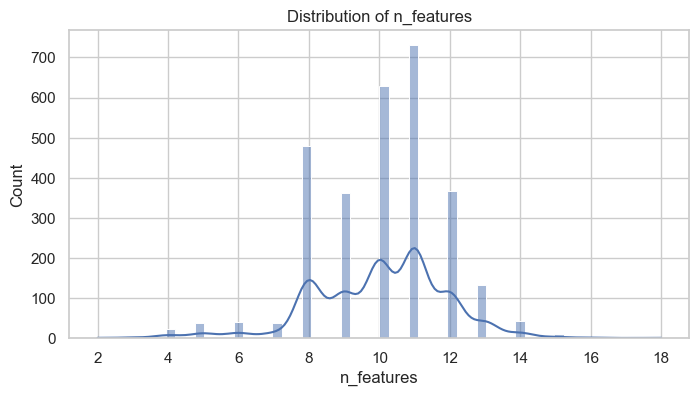

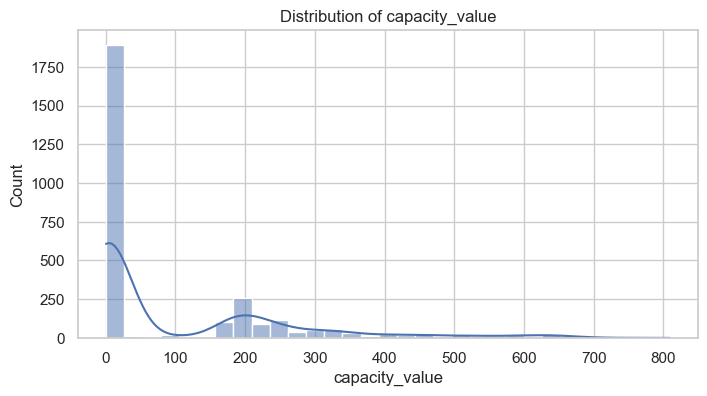

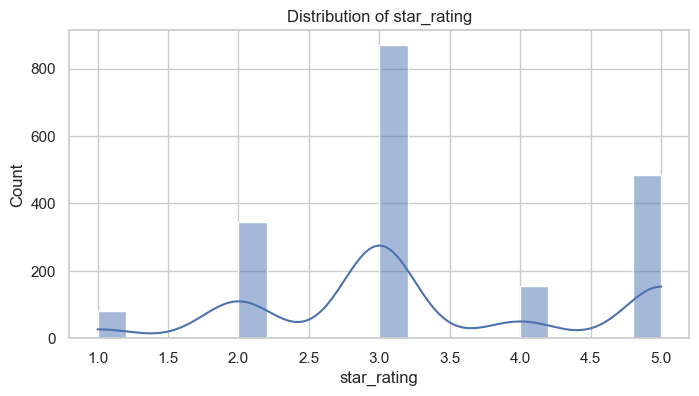

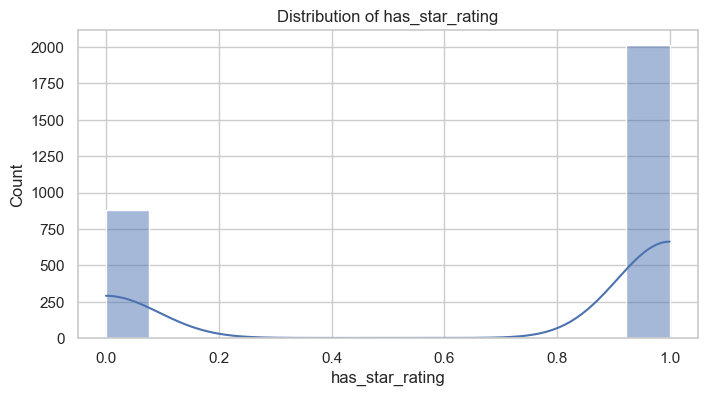

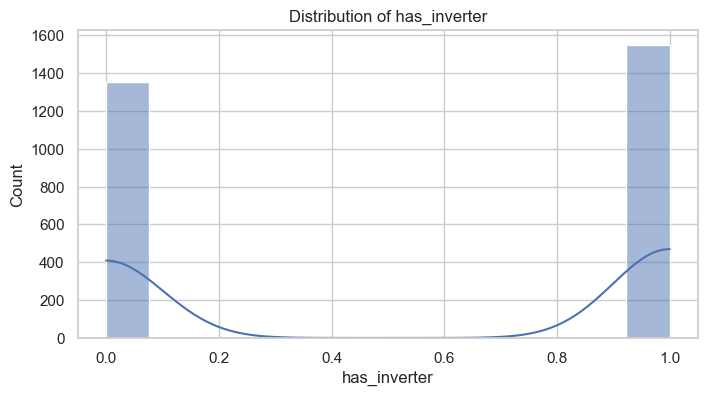

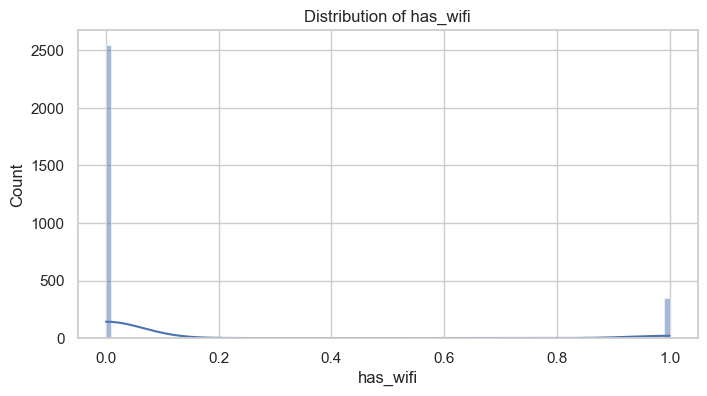

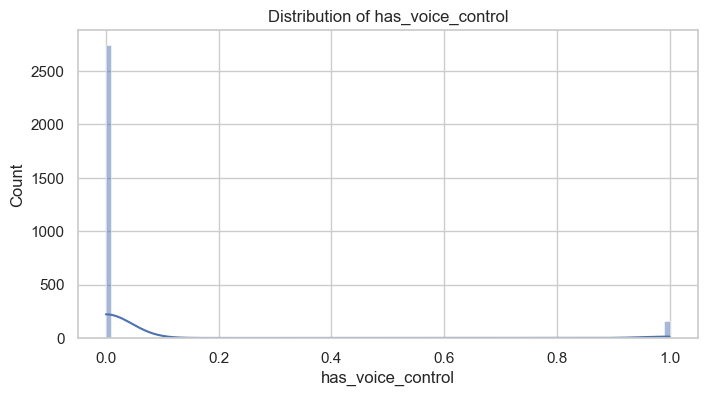

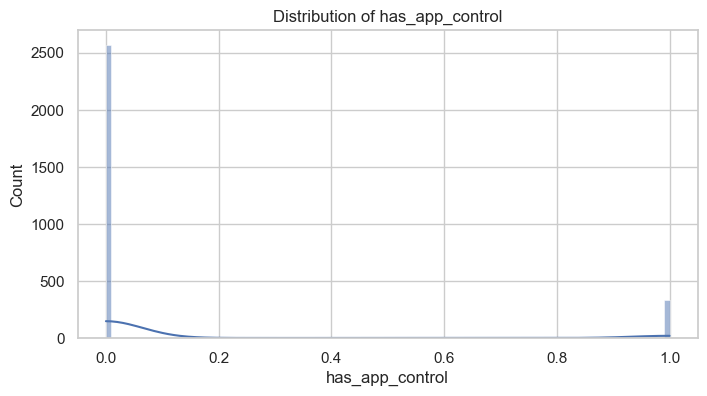

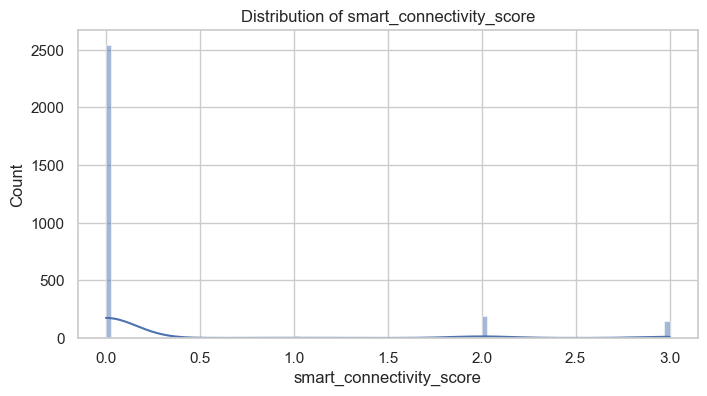

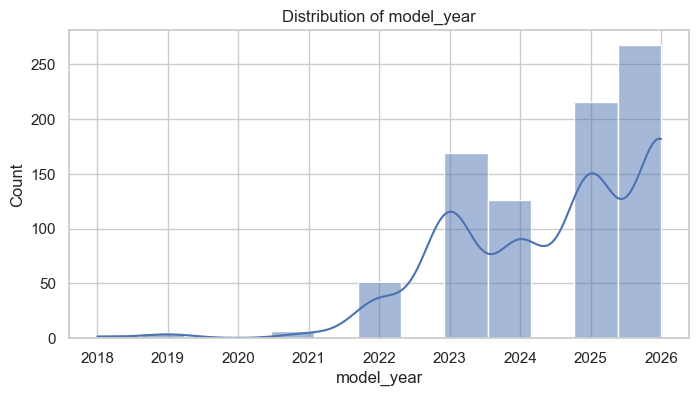

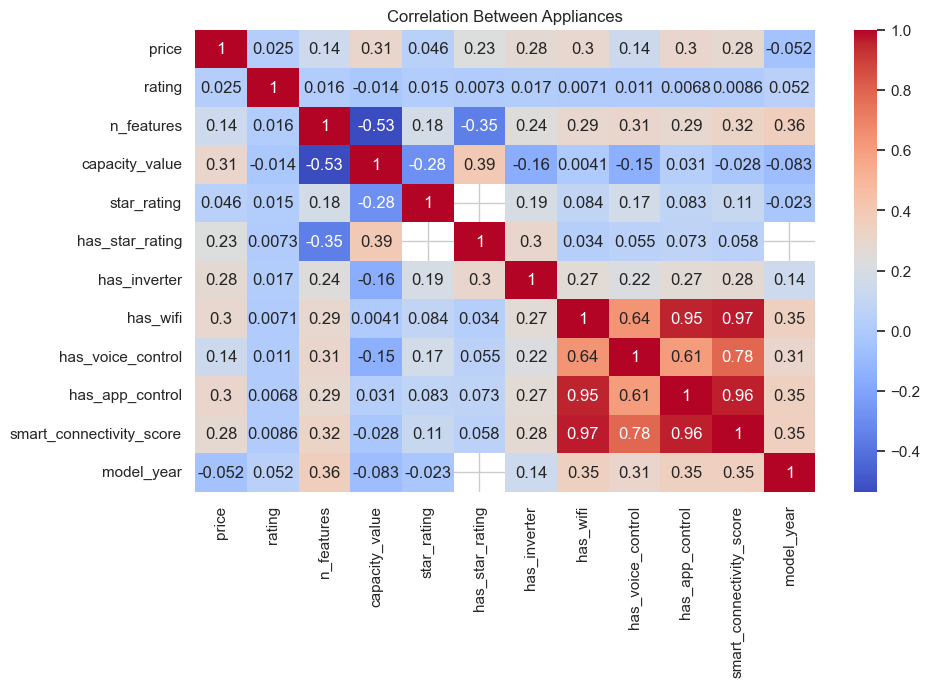

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot distributions for numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# Correlation heatmap (if multiple appliances)
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Appliances")
plt.show()

**A. Target-Related Missing :**

In [48]:
print('Percentage of Missing Data :')
print(f'Star Ratings : {df['star_rating'].isna().mean()*100}')
print(f'Model Year : {df['model_year'].isna().mean()*100}')


Percentage of Missing Data :
Star Ratings : 33.241379310344826
Model Year : 70.93103448275862


- We have to fill with category medians.

In [55]:
df.isna().mean()*100

price                        0.000000
rating                       0.000000
category                     0.000000
n_features                   0.000000
brand_name                   0.000000
capacity_value               0.000000
capacity_unit                0.000000
star_rating                 33.241379
has_star_rating              0.000000
has_inverter                 0.000000
has_wifi                     0.000000
has_voice_control            0.000000
has_app_control              0.000000
smart_connectivity_score     0.000000
model_year                  70.931034
is_recent_model             70.931034
appliance_age               70.931034
ac_split                    65.206897
ac_window                   65.206897
ac_pm25_filter              65.206897
ac_hepa_filter              65.206897
ac_auto_clean               65.206897
ac_hot_and_cold             65.206897
ac_copper_condenser         65.206897
ac_Dehumidification         65.206897
ac_Turbo Mode               65.206897
ac_Self Diag

- There are many category specific columns having more than 70% data missing
- We must impute those columns with 0 (product doesn't have this feature)

**Capacity-Price relationship**

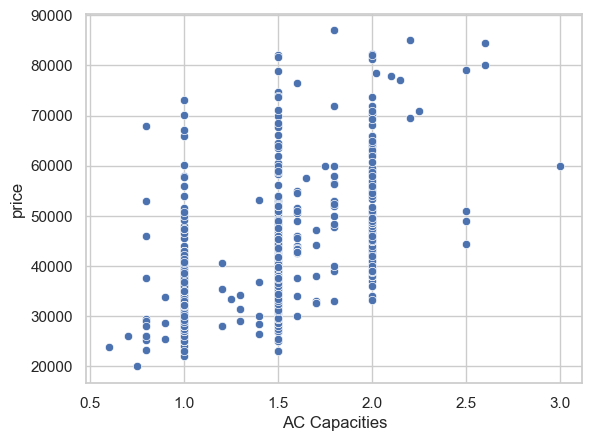

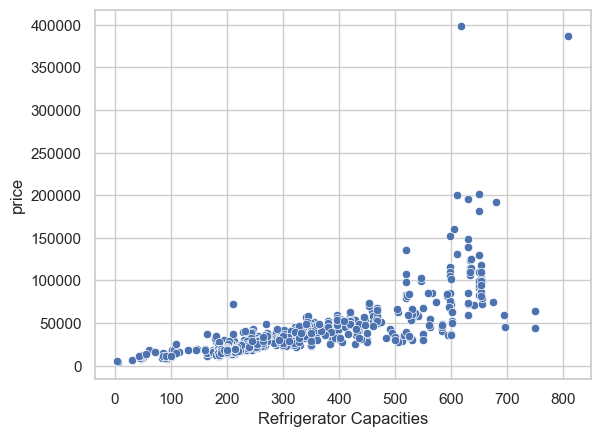

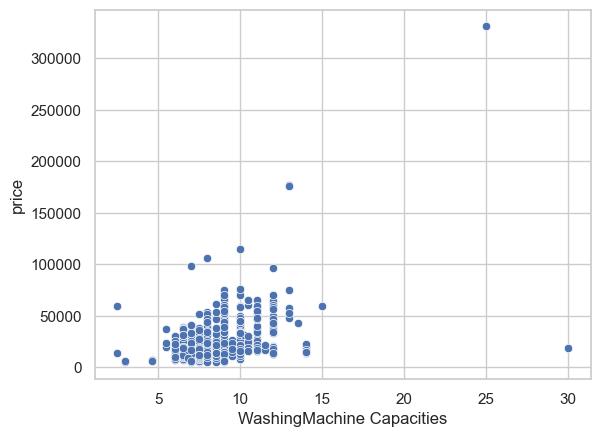

In [59]:
cat = ['AC','Refrigerator','WashingMachine']
for c in cat:
    data = df[df['category']==c]
    sns.scatterplot(data=data,x='capacity_value',y='price')
    plt.xlabel(f'{c} Capacities')
    plt.show()

- **There is somewhat linearity in capacities and Prices**

**Key Insight**: Capacity matters differently across categories. This justifies:
1. **OneHotEncode Capacity value column to get category specific capacities**
2. **Interaction terms**: capacity × category, capacity × brand
3. **Non-linear scaling**: Capacity impact increases with category

### **Feature-Target Relationships**

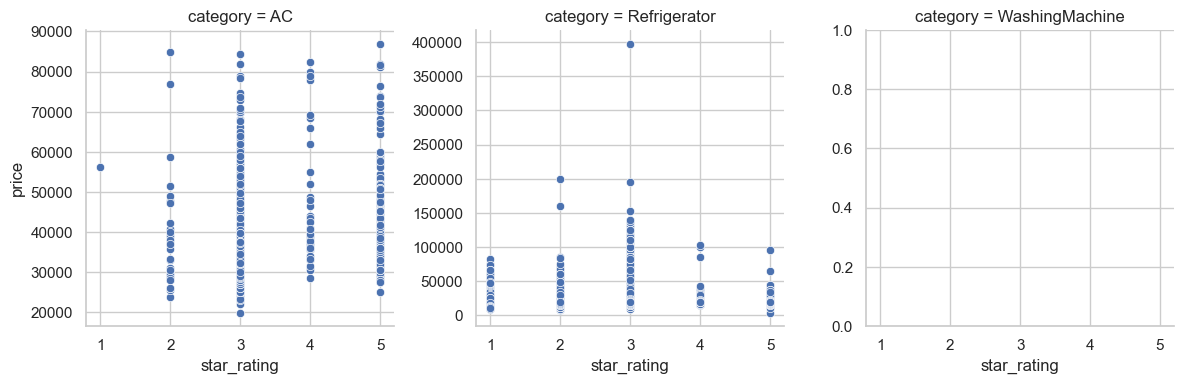

In [ ]:
# Star Ratings VS Price
sns.relplot(
    data=df,
    x='star_rating',
    y='price',
    col='category',
    kind='scatter',
    col_wrap=3,
    height=4,
    aspect=1,
    facet_kws={'sharey': False}
)

plt.show()

- There are more ACs with 5 star ratings and higher price, whereas 3 star rating are in medium range
- Refrigerator: We see most fridges are 3 star ratings and it ranges throughout.

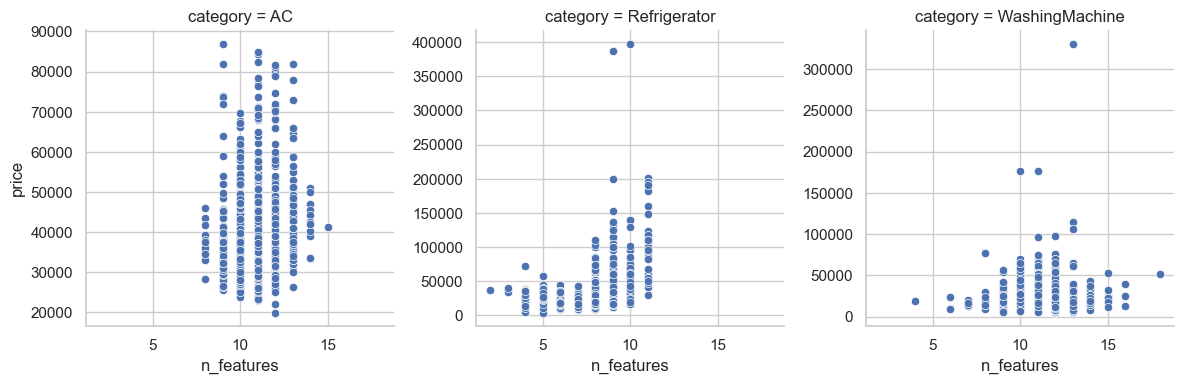

In [ ]:
# Number of features VS Price
sns.relplot(
    data=df,
    x='n_features',
    y='price',
    col='category',
    kind='scatter',
    col_wrap=3,
    height=4,
    aspect=1,
    facet_kws={'sharey': False}
)

plt.show()

In [77]:
df.info()

<class 'pandas.DataFrame'>
Index: 2900 entries, 0 to 2924
Data columns (total 54 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     2900 non-null   int64  
 1   rating                    2900 non-null   float64
 2   category                  2900 non-null   str    
 3   n_features                2900 non-null   int64  
 4   brand_name                2900 non-null   str    
 5   capacity_value            2900 non-null   float64
 6   capacity_unit             2900 non-null   str    
 7   star_rating               1936 non-null   float64
 8   has_star_rating           2900 non-null   int64  
 9   has_inverter              2900 non-null   int64  
 10  has_wifi                  2900 non-null   int64  
 11  has_voice_control         2900 non-null   int64  
 12  has_app_control           2900 non-null   int64  
 13  smart_connectivity_score  2900 non-null   int64  
 14  model_year              

In [ ]:

# Price outliers
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    return (data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)

price_outliers = detect_outliers_iqr(df['price'])
print(f"Price outliers: {price_outliers.sum()} ({price_outliers.sum()/len(df)*100:.1f}%)")
print(f"Range: ₹{df[price_outliers]['price'].min():.0f} - ₹{df[price_outliers]['price'].max():.0f}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df[~price_outliers].index, df[~price_outliers]['price'], 
          alpha=0.5, label='Normal', s=30)
ax.scatter(df[price_outliers].index, df[price_outliers]['price'], 
          alpha=0.7, label='Outliers', s=50, color='red')
ax.set_title('Price Outliers Detection (IQR method)')
ax.set_xlabel('Product Index')
ax.set_ylabel('Price (₹)')
ax.legend()
plt.tight_layout()
plt.savefig('outliers_detection.png', dpi=300)

Price outliers: 102 (3.5%)
Range: ₹71899 - ₹397990
